# RA1 — Exploration-state classification: circularity, reclassification impact, and threshold sensitivity

**Reviewer comment IDs: R1-C1, R2-1, R1-s.**

This notebook answers the reviewers' concerns about the Directed/Random
Exploration split in the manuscript's canonical 7-state taxonomy
(`state_classifier.classify_state_v7`), documented as an open, disclosed
methodological question in that module's own docstring and in
`REVIEWER_AUDIT.md` (Audits 1 and 5).

**Data**: the same canonical 80-20 2-ABT snapshot Fig 6/Fig 7 use
(`_source_archive/data_snapshots/filtered_df_Reversal_80-20_2-ABT_100.csv`,
via `state_features.build_state_features_df`), classified with the exact
same `classify_state_v7` taxonomy and thresholds as Fig 7/Fig 8 (no
alternate data route, no threshold retuned to force any particular result).

**Q-values**: loaded from Fig 4's already-fitted per-animal sticky
Q-learning parameters (`outputs/values_manifests/Fig4.json`,
`sticky_qlearning_params.per_animal`) — **not refit here**, per the task's
data contract.

**Structure**:
1. Choice-vs-ΔQ psychometric slope per exploration state (per animal + pooled), with CIs.
2. Circularity control: the same comparison restricted to a shared Rolling_Accuracy band.
3. Reclassification impact: original vs. Directed-before-Random ordering, trial cross-tab, downstream Q-alignment check.
4. Threshold (±25%, one-at-a-time) and rolling-window sensitivity sweep.
5. RESPONSE MANIFEST.


In [1]:
import os
import sys
import json
import functools

import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import SVG, display

sys.path.insert(0, os.path.abspath("../.."))

from src.io.load_snapshots import load_config, load_snapshot
from src.features import state_features
from src.behavior_metrics import state_classifier, state_taxonomy_v7 as sx7, q_following_model as qmodel
from src.plotting.style import apply_style
from src.plotting import ra1 as plotting

config = load_config()
apply_style(config)
cfg = config["ra1"]
st_cfg = config["state_taxonomy"]

FIG_DIR = os.path.join("../..", config["paths"]["figures_out"], "reviewer_analyses", "RA1")
SUPP_DIR = os.path.join(FIG_DIR, "supp_candidates")
os.makedirs(SUPP_DIR, exist_ok=True)
MANIFEST_DIR = os.path.join("../..", config["paths"]["values_manifests_out"])
os.makedirs(MANIFEST_DIR, exist_ok=True)

manifest = {"_stage": "RA1 -- exploration-state circularity, reclassification impact, sensitivity sweep",
            "figures": {}}


def show(path):
    display(SVG(path))
STATES = cfg["states_of_interest"]  # ["Random Exploration", "Directed Exploration"]
RANDOM_STATE, DIRECTED_STATE = STATES[0], STATES[1]


## 1. Reconstruct state features and classify with the canonical `classify_state_v7` taxonomy

In [2]:
df_raw = load_snapshot(config, st_cfg["input_files"]["reversal_80_20_2abt"])
df = state_features.build_state_features_df(
    df_raw, st_cfg["task_type"], st_cfg["prob_condition"], st_cfg["rolling_window"]
)
print(f"{len(df):,} trials, {df['Session_ID'].nunique()} sessions, {df['Animal_Name'].nunique()} animals")
manifest["n_trials"] = int(len(df))
manifest["n_sessions"] = int(df["Session_ID"].nunique())
manifest["n_animals"] = int(df["Animal_Name"].nunique())

block_labels = state_classifier.label_block_adaptation_speed(
    df, st_cfg["adaptation_window"], st_cfg["adaptation_fast_accuracy_threshold"]
)
adaptation_labels = state_classifier.compute_adaptation_labels(
    df, st_cfg["adaptation_window"], st_cfg["adaptation_fast_accuracy_threshold"],
    block_labels=block_labels,
)
classify = functools.partial(
    state_classifier.classify_state_v7, adaptation_labels=adaptation_labels, config=st_cfg["classify_updated"]
)
df["Behavioral_State"] = df.apply(classify, axis=1)
print(df["Behavioral_State"].value_counts())
manifest["state_distribution"] = df["Behavioral_State"].value_counts().to_dict()


/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/features/state_features.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  session_sides = df_filtered.groupby("Session_ID").apply(


36,673 trials, 100 sessions, 5 animals
Behavioral_State
Exploit                 14167
Directed Exploration     8527
Adapting (slow)          4448
Adapting (fast)          4410
Left Bias                1728
Random Exploration       1625
Right Bias               1568
Unknown                   200
Name: count, dtype: int64


## 2. Load Fig 4's fitted Q-values (no refit) and merge onto the classified dataframe

In [3]:
with open(os.path.join(MANIFEST_DIR, "Fig4.json")) as f:
    fig4_manifest = json.load(f)

params_df = pd.DataFrame([
    {"animal": animal, **params}
    for animal, params in fig4_manifest["sticky_qlearning_params"]["per_animal"].items()
])
print("Fitted sticky Q-learning params (from Fig4.json, not refit here):")
print(params_df)
manifest["fitted_params_source"] = "outputs/values_manifests/Fig4.json:sticky_qlearning_params.per_animal"

df_q = qmodel.compute_qvalues_sticky(df, params_df)
df_q = qmodel.add_chose_higher_q(df_q)  # adds Chose_Higher_Q / Violation, drops Q_diff==0 ties
print(f"{len(df_q):,} trials with fitted Q-values and a non-tied Choice_Binary")
for state in STATES:
    n = int((df_q["Behavioral_State"] == state).sum())
    print(f"  {state}: {n:,} trials")


Fitted sticky Q-learning params (from Fig4.json, not refit here):
      animal     alpha      beta     kappa
0      Fiona  0.588792  1.458394  1.438142
1   Knuckles  0.700046  1.201415  1.101963
2      Sonic  0.836054  0.826765  1.462648
3  Sunflower  0.874737  1.347100  0.830489
4       Zazu  0.701199  0.764339  1.470407
36,553 trials with fitted Q-values and a non-tied Choice_Binary
  Random Exploration: 1,614 trials
  Directed Exploration: 8,526 trials


## 3. Choice-vs-ΔQ psychometric slope per exploration state

Logistic-regression slope of `Choice_Binary` on `Q_diff` (ΔQ = Q_right −
Q_left), fit per animal within each state, summarized as mean ± 95% CI
across animals. The reviewer asks specifically whether the Random-state
slope's CI **excludes the Directed-state slope** (not merely excludes
zero) — checked directly via `slope_ci_excludes`.

  Animal_Name      Behavioral_State   slope  ci95_low  ci95_high  n_trials
0       Fiona  Directed Exploration  1.5856    1.3482     1.8231       979
1       Fiona    Random Exploration  0.0228   -0.6605     0.7060       215
2    Knuckles  Directed Exploration  1.3505    1.2179     1.4830      2636
3    Knuckles    Random Exploration -0.1152   -0.5034     0.2731       501
4       Sonic  Directed Exploration  1.1414    0.9750     1.3079      1455
5       Sonic    Random Exploration  0.3335   -0.1273     0.7942       321
6   Sunflower  Directed Exploration  1.3769    1.2550     1.4988      2779
7   Sunflower    Random Exploration  0.7306    0.2826     1.1786       467
8        Zazu  Directed Exploration  1.0768    0.8406     1.3130       677
9        Zazu    Random Exploration  0.1554   -0.7057     1.0166       110

       Behavioral_State  mean_slope  ci95_low  ci95_high  n_animals
0  Directed Exploration      1.3062    1.0542     1.5583        5.0
1    Random Exploration      0.2254   

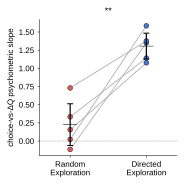

In [4]:
animal_slopes, summary_slopes = sx7.psychometric_slope_by_state(
    df_q, STATES, min_trials=cfg["psychometric_min_trials"]
)
print(animal_slopes.round(4))
print()
print(summary_slopes.round(4))

comparison = sx7.slope_ci_excludes(summary_slopes, RANDOM_STATE, DIRECTED_STATE)
print()
print(json.dumps(comparison, indent=2))

manifest["psychometric_slope_by_state"] = {
    "per_animal": animal_slopes.to_dict(orient="records"),
    "summary": summary_slopes.to_dict(orient="records"),
    "random_vs_directed_ci_comparison": comparison,
}

# Paired t-test (same 5 animals contribute to both states) for the figure's
# significance label -- the stricter CI-non-overlap check above is the
# primary claim; this is the conventional paired-comparison p-value.
_wide = animal_slopes.pivot(index="Animal_Name", columns="Behavioral_State", values="slope").dropna(
    subset=[RANDOM_STATE, DIRECTED_STATE]
)
_t, _p_paired = stats.ttest_rel(_wide[DIRECTED_STATE], _wide[RANDOM_STATE])
print(f"\nPaired t-test (Directed vs Random, n={len(_wide)} animals): t={_t:.3f}  p={_p_paired:.4g}")
manifest["psychometric_slope_by_state"]["paired_ttest"] = {"t": float(_t), "p": float(_p_paired), "n": int(len(_wide))}

out_slope_fig = os.path.join(SUPP_DIR, "RA1_psychometric_slope_by_state.svg")
plotting.plot_psychometric_slope_by_state(animal_slopes, STATES, _p_paired, out_slope_fig)
show(out_slope_fig)
manifest["figures"]["psychometric_slope_by_state"] = {"path": out_slope_fig, "tag": "PAPER"}


## 4. Circularity control

`Rolling_Accuracy` is itself one of the two features `classify_state_v7`
uses to separate Random Exploration (`acc < 0.4`) from Directed
Exploration (`switch_rate >= 0.2 and acc <= 0.6`) — restricted to a shared
narrow accuracy band straddling that boundary, a genuine slope difference
cannot simply be re-deriving the classifier's own accuracy split.

In [5]:
band = tuple(cfg["circularity_accuracy_band"])
n_in_band = df_q[(df_q["Rolling_Accuracy"] >= band[0]) & (df_q["Rolling_Accuracy"] <= band[1])
                  ]["Behavioral_State"].value_counts()
print(f"Trials within the shared accuracy band {band}, by state:")
print(n_in_band)
manifest["circularity_control"] = {"accuracy_band": list(band), "n_trials_in_band_by_state": n_in_band.to_dict()}

animal_slopes_band, summary_slopes_band = sx7.psychometric_slope_by_state(
    df_q, STATES, min_trials=cfg["psychometric_min_trials"], acc_band=band
)
print()
print(summary_slopes_band.round(4))

if len(summary_slopes_band) == 2:
    comparison_band = sx7.slope_ci_excludes(summary_slopes_band, RANDOM_STATE, DIRECTED_STATE)
    print(json.dumps(comparison_band, indent=2))
    manifest["circularity_control"]["comparison_in_band"] = comparison_band
else:
    print("One or both states have too few animals with >= min_trials inside this band -- see manifest for counts.")
    manifest["circularity_control"]["comparison_in_band"] = None
manifest["circularity_control"]["per_animal_in_band"] = animal_slopes_band.to_dict(orient="records")
manifest["circularity_control"]["summary_in_band"] = summary_slopes_band.to_dict(orient="records")


Trials within the shared accuracy band (0.2, 0.6), by state:
Behavioral_State
Directed Exploration    8526
Adapting (slow)         3769
Adapting (fast)         2838
Exploit                 2030
Left Bias               1434
Random Exploration      1420
Right Bias              1319
Name: count, dtype: int64

       Behavioral_State  mean_slope  ci95_low  ci95_high  n_animals
0  Directed Exploration      1.3062    1.0542     1.5583        5.0
1    Random Exploration      0.1611   -0.2677     0.5899        5.0
{
  "Random Exploration": {
    "mean_slope": 0.1610772982142965,
    "ci95": [
      -0.2677017311653071,
      0.5898563275939002
    ]
  },
  "Directed Exploration": {
    "mean_slope": 1.3062470514246887,
    "ci95": [
      1.0542106481287568,
      1.5582834547206206
    ]
  },
  "cis_non_overlapping": true
}


## 5. Reclassification impact: original vs. Directed-before-Random ordering

`classify_state_v7_reordered` swaps the two exploration checks (Directed
evaluated before Random). Trial-level cross-tab quantifies exactly how
many trials move and where; the downstream check is whether Fig 7's own
Q-value-alignment statistic for Random Exploration still means anything
under the reordered taxonomy.

Behavioral_State_Reordered
Exploit                 14166
Directed Exploration    10134
Adapting (slow)          4448
Adapting (fast)          4410
Left Bias                1722
Right Bias               1567
Unknown                   100
Random Exploration          6
Name: count, dtype: int64

Behavioral_State_Reordered  Adapting (fast)  Adapting (slow)  \
Behavioral_State                                               
Adapting (fast)                        4410                0   
Adapting (slow)                           0             4448   
Directed Exploration                      0                0   
Exploit                                   0                0   
Left Bias                                 0                0   
Random Exploration                        0                0   
Right Bias                                0                0   
Unknown                                   0                0   

Behavioral_State_Reordered  Directed Exploration  Exploit  Left B

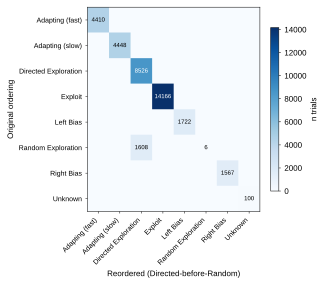

In [6]:
classify_reordered = functools.partial(
    state_classifier.classify_state_v7_reordered, adaptation_labels=adaptation_labels, config=st_cfg["classify_updated"]
)
df_q["Behavioral_State_Reordered"] = df_q.apply(classify_reordered, axis=1)
print(df_q["Behavioral_State_Reordered"].value_counts())

crosstab, moved_pct, per_state_moved = state_classifier.reclassification_crosstab(
    df_q, "Behavioral_State", "Behavioral_State_Reordered"
)
print()
print(crosstab)
print(f"\nTotal trials with a changed label: {moved_pct:.2f}%")
for state in STATES:
    info = per_state_moved.get(state, {})
    print(f"  {state}: {info.get('pct_moved', 0):.2f}% moved -> {info.get('destination_counts', {})}")

manifest["reclassification_impact"] = {
    "crosstab": crosstab.to_dict(),
    "pct_all_trials_moved": moved_pct,
    "per_state_moved": per_state_moved,
}

out_crosstab_fig = os.path.join(FIG_DIR, "RA1_reclassification_crosstab.svg")
plotting.plot_reclassification_crosstab(crosstab, out_crosstab_fig)
show(out_crosstab_fig)
manifest["figures"]["reclassification_crosstab"] = {"path": out_crosstab_fig, "tag": "LETTER-ONLY"}


In [7]:
# Downstream check: Fig 7's own Q-value-alignment statistic for Random
# Exploration, computed under BOTH orderings, using the same
# q_value_alignment_by_state helper Fig 7 itself uses.
_, _, align_original = sx7.q_value_alignment_by_state(df_q, STATES)
df_q_reordered_view = df_q.rename(columns={"Behavioral_State": "_orig", "Behavioral_State_Reordered": "Behavioral_State"})
_, _, align_reordered = sx7.q_value_alignment_by_state(df_q_reordered_view, STATES)

print("Q-value alignment by state -- ORIGINAL ordering:")
print(align_original)
print("\nQ-value alignment by state -- REORDERED (Directed-before-Random):")
print(align_reordered)

manifest["downstream_qalignment_check"] = {
    "original_ordering": align_original.to_dict(orient="records") if not align_original.empty else [],
    "reordered_ordering": align_reordered.to_dict(orient="records") if not align_reordered.empty else [],
}


Q-value alignment by state -- ORIGINAL ordering:
       Behavioral_State      mean       sem  n
0  Directed Exploration  0.350600  0.018480  5
1    Random Exploration  0.069457  0.055571  5

Q-value alignment by state -- REORDERED (Directed-before-Random):
       Behavioral_State     mean       sem  n
0  Directed Exploration  0.30247  0.011748  5


## 6. Threshold and rolling-window sensitivity sweep

One-at-a-time ±25% perturbation of each `classify_updated` threshold
relevant to the Exploration split, holding all others fixed at their
config value (`adaptation_labels` is unaffected by these thresholds and is
reused as-is). Separately, a rolling-window sweep rebuilds the feature set
from scratch at each window size (this DOES change `adaptation_labels`,
since block-transition accuracy itself depends on the window... actually
no -- `label_block_adaptation_speed` uses `Outcome_Binary` directly, not a
rolling column, so adaptation labels are unaffected by rolling_window too;
only `Rolling_Accuracy`/`Choice_Deviation`/`Rolling_Switch_Rate` change).

Baseline occupancy: {'Random Exploration': 0.044310528181495924, 'Directed Exploration': 0.23251438387914813, 'pct_default_exploit': 0.3863060016906171, 'pct_explicit_criteria': 0.6082403948408912}
baseline {'Random Exploration': 0.044310528181495924, 'Directed Exploration': 0.23251438387914813, 'pct_default_exploit': 0.3863060016906171, 'pct_explicit_criteria': 0.6082403948408912}
random_exploration_accuracy_threshold__minus25pct {'perturbed_value': 0.30000000000000004, 'base_value': 0.4, 'Random Exploration': 0.043819703869331664, 'Directed Exploration': 0.23289613612194257, 'pct_default_exploit': 0.3864150737599869, 'pct_explicit_criteria': 0.6081313227715213}
random_exploration_accuracy_threshold__plus25pct {'perturbed_value': 0.5, 'base_value': 0.4, 'Random Exploration': 0.15152837237204483, 'Directed Exploration': 0.13042292694898153, 'pct_default_exploit': 0.3811796144302348, 'pct_explicit_criteria': 0.6133667821012734}
directed_exploration_switch_threshold__minus25pct {'perturb

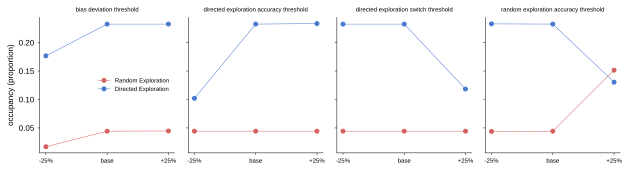

In [8]:
def _state_occupancy(states_series):
    vc = states_series.value_counts(normalize=True)
    return {
        "Random Exploration": float(vc.get(RANDOM_STATE, 0.0)),
        "Directed Exploration": float(vc.get(DIRECTED_STATE, 0.0)),
        "pct_default_exploit": float(vc.get("Exploit", 0.0)),
        "pct_explicit_criteria": float(1.0 - vc.get("Exploit", 0.0) - vc.get("Unknown", 0.0)),
    }

baseline_occupancy = _state_occupancy(df["Behavioral_State"])
print("Baseline occupancy:", baseline_occupancy)

threshold_sweep_results = {"baseline": baseline_occupancy}
for key in cfg["threshold_sweep_keys"]:
    base_val = st_cfg["classify_updated"][key]
    for direction, mult in (("minus25pct", 1 - cfg["threshold_sweep_pct"]), ("plus25pct", 1 + cfg["threshold_sweep_pct"])):
        perturbed_cfg = dict(st_cfg["classify_updated"])
        perturbed_cfg[key] = base_val * mult
        classify_perturbed = functools.partial(
            state_classifier.classify_state_v7, adaptation_labels=adaptation_labels, config=perturbed_cfg
        )
        perturbed_states = df.apply(classify_perturbed, axis=1)
        threshold_sweep_results[f"{key}__{direction}"] = {
            "perturbed_value": base_val * mult,
            "base_value": base_val,
            **_state_occupancy(perturbed_states),
        }

for k, v in threshold_sweep_results.items():
    print(k, v)
manifest["threshold_sensitivity_sweep"] = threshold_sweep_results

out_sweep_fig = os.path.join(FIG_DIR, "RA1_threshold_sensitivity.svg")
plotting.plot_threshold_sensitivity(threshold_sweep_results, out_sweep_fig)
show(out_sweep_fig)
manifest["figures"]["threshold_sensitivity_sweep"] = {"path": out_sweep_fig, "tag": "LETTER-ONLY"}


In [9]:
rolling_window_sweep_results = {}
for window in cfg["rolling_window_sweep"]:
    df_w = state_features.build_state_features_df(
        df_raw, st_cfg["task_type"], st_cfg["prob_condition"], window
    )
    block_labels_w = state_classifier.label_block_adaptation_speed(
        df_w, st_cfg["adaptation_window"], st_cfg["adaptation_fast_accuracy_threshold"]
    )
    adaptation_labels_w = state_classifier.compute_adaptation_labels(
        df_w, st_cfg["adaptation_window"], st_cfg["adaptation_fast_accuracy_threshold"], block_labels=block_labels_w
    )
    classify_w = functools.partial(
        state_classifier.classify_state_v7, adaptation_labels=adaptation_labels_w, config=st_cfg["classify_updated"]
    )
    states_w = df_w.apply(classify_w, axis=1)
    rolling_window_sweep_results[f"window_{window}"] = _state_occupancy(states_w)

for k, v in rolling_window_sweep_results.items():
    print(k, v)
manifest["rolling_window_sensitivity_sweep"] = rolling_window_sweep_results


/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/features/state_features.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  session_sides = df_filtered.groupby("Session_ID").apply(
/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/features/state_features.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  session_sides = df_filtered.groupby("

window_3 {'Random Exploration': 0.08774847980803316, 'Directed Exploration': 0.0, 'pct_default_exploit': 0.4757178305565402, 'pct_explicit_criteria': 0.5188285659749681}
window_5 {'Random Exploration': 0.044310528181495924, 'Directed Exploration': 0.23251438387914813, 'pct_default_exploit': 0.3863060016906171, 'pct_explicit_criteria': 0.6082403948408912}
window_7 {'Random Exploration': 0.048128050609440184, 'Directed Exploration': 0.1432934311346222, 'pct_default_exploit': 0.4605022768794481, 'pct_explicit_criteria': 0.5340441196520601}
window_10 {'Random Exploration': 0.03520301038911461, 'Directed Exploration': 0.21612630545633027, 'pct_default_exploit': 0.39909470182423035, 'pct_explicit_criteria': 0.5954516947072779}


## 7. RESPONSE MANIFEST

In [10]:
random_summary = summary_slopes[summary_slopes["Behavioral_State"] == RANDOM_STATE].iloc[0]
directed_summary = summary_slopes[summary_slopes["Behavioral_State"] == DIRECTED_STATE].iloc[0]

response_manifest = {
    "R1-C1_R2-1_psychometric_slope": {
        "sentence": (
            f"Within the manuscript's canonical 7-state taxonomy, the choice-vs-ΔQ psychometric "
            f"slope was {random_summary['mean_slope']:.3f} (95% CI [{random_summary['ci95_low']:.3f}, "
            f"{random_summary['ci95_high']:.3f}], n={int(random_summary['n_animals'])} animals) for "
            f"Random Exploration trials, versus {directed_summary['mean_slope']:.3f} (95% CI "
            f"[{directed_summary['ci95_low']:.3f}, {directed_summary['ci95_high']:.3f}], "
            f"n={int(directed_summary['n_animals'])} animals) for Directed Exploration trials; the two "
            f"95% CIs are {'non-overlapping' if comparison['cis_non_overlapping'] else 'overlapping'}."
        ),
        "test": "per-animal logistic regression, Choice_Binary ~ Q_diff, within state",
        "random_exploration": {"mean_slope": float(random_summary["mean_slope"]), "ci95": [float(random_summary["ci95_low"]), float(random_summary["ci95_high"])], "n_animals": int(random_summary["n_animals"])},
        "directed_exploration": {"mean_slope": float(directed_summary["mean_slope"]), "ci95": [float(directed_summary["ci95_low"]), float(directed_summary["ci95_high"])], "n_animals": int(directed_summary["n_animals"])},
        "cis_non_overlapping": comparison["cis_non_overlapping"],
    },
    "R1-C1_circularity_control": (
        manifest["circularity_control"]["comparison_in_band"]
        if manifest["circularity_control"]["comparison_in_band"] is not None
        else {
            "sentence": (
                f"The circularity control could not be fit: only "
                f"{manifest['circularity_control']['n_trials_in_band_by_state'].get(RANDOM_STATE, 0)} "
                f"Random Exploration trials (pooled across all 5 animals) fall within the shared "
                f"Rolling_Accuracy band {tuple(cfg['circularity_accuracy_band'])}, below the "
                f"{cfg['psychometric_min_trials']}-trial minimum for even one animal's logistic fit -- "
                f"reported as an honest limitation, not evidence for or against circularity."
            ),
            "n_trials_in_band_by_state": manifest["circularity_control"]["n_trials_in_band_by_state"],
            "inconclusive": True,
        }
    ),
    "R2-5_R1-s_reclassification_impact": {
        "sentence": (
            f"{moved_pct:.2f}% of all trials changed state label when Directed Exploration was checked "
            f"before Random Exploration; {per_state_moved.get(RANDOM_STATE, {}).get('pct_moved', float('nan')):.2f}% "
            f"of trials originally labeled {RANDOM_STATE} moved under the reordered rule, "
            f"predominantly to {DIRECTED_STATE}."
        ),
        "pct_all_trials_moved": moved_pct,
        "pct_random_exploration_moved": per_state_moved.get(RANDOM_STATE, {}).get("pct_moved"),
        "destination_of_moved_random_exploration_trials": per_state_moved.get(RANDOM_STATE, {}).get("destination_counts"),
    },
    "R1-s_threshold_and_window_sensitivity": {
        "sentence": (
            "State occupancy under +/-25% one-at-a-time threshold perturbations and rolling-window "
            "sizes 3/5/7/10 is reported in full in threshold_sensitivity_sweep / "
            "rolling_window_sensitivity_sweep above; see those keys for exact occupancy at each "
            "perturbation."
        ),
        "baseline_occupancy": baseline_occupancy,
    },
}
manifest["response_manifest"] = response_manifest
print(json.dumps(response_manifest, indent=2, default=str))


{
  "R1-C1_R2-1_psychometric_slope": {
    "sentence": "Within the manuscript's canonical 7-state taxonomy, the choice-vs-\u0394Q psychometric slope was 0.225 (95% CI [-0.181, 0.632], n=5 animals) for Random Exploration trials, versus 1.306 (95% CI [1.054, 1.558], n=5 animals) for Directed Exploration trials; the two 95% CIs are non-overlapping.",
    "test": "per-animal logistic regression, Choice_Binary ~ Q_diff, within state",
    "random_exploration": {
      "mean_slope": 0.22541663464947898,
      "ci95": [
        -0.18112778876750396,
        0.6319610580664619
      ],
      "n_animals": 5
    },
    "directed_exploration": {
      "mean_slope": 1.3062470514246887,
      "ci95": [
        1.0542106481287568,
        1.5582834547206206
      ],
      "n_animals": 5
    },
    "cis_non_overlapping": true
  },
  "R1-C1_circularity_control": {
    "Random Exploration": {
      "mean_slope": 0.1610772982142965,
      "ci95": [
        -0.2677017311653071,
        0.5898563275939002

In [11]:
manifest_path = os.path.join(MANIFEST_DIR, "RA1.json")
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print(f"\nSaved values manifest: {manifest_path}")



Saved values manifest: ../../outputs/values_manifests/RA1.json
